In [1]:
import os

from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_io as tfio

2026-04-19 20:19:31.642737: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-19 20:19:31.660585: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-19 20:19:31.660610: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-19 20:19:31.661165: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-19 20:19:31.664779: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Se carga YAMNet
yamnet_model_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet_model = hub.load(yamnet_model_handle)

2026-04-19 20:19:35.240790: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-19 20:19:35.266512: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-19 20:19:35.269243: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

### Construcción y Entrenamiento del clasificador con los embeddings de YAMNet concatenados


Para tratar de mitigar los inconvenientes que se detallan en la nota abajo se plantea:  

Dado que todos los clips:
- duran lo mismo,
- están a 16 kHz,
- y por lo tanto producen la misma cantidad de embeddings temporales.
**concatenar todos los embeddings del clip** y representar cada clip con un único vector largo.

Como cada clip produce N embeddings y cada embedding tiene dimensión 1024, entonces cada clip quedaría representado por un vector de tamaño: N * 1024

NOTA: Inicialmente se entrenó el clasificador empleando los embedding individuales obtenidos de YAMNet y los resultados no fueron satisfactorios y se supuso consecuencia de ruido de etiqueta dado que  todos los embeddings individuales heredaran la clase del clip (12 por audio).

Se usa:
- un clip completo de 6 s
- YAMNet lo divide en ventanas temporales
- a cada embedding temporal se le asigna la class_id del clip completo

No todos los embeddings del clip necesariamente contienen información clara del ave.

Dentro de un clip etiquetado como una especie puede haber:
- silencio
- ruido de fondo
- otras vocalizaciones débiles
- padding/contexto ambiental
- frames donde el canto principal casi no está

Entonces se entrena introduciendo mucho ruido en la clase (label noise)

Ver https://www.tensorflow.org/tutorials/audio/transfer_learning_audio?hl=es-419

In [17]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()
gc.collect()

9601

In [4]:
from pathlib import Path
# Se definen todas las constantes en forma redundante.
DATASET_ROOT = Path("dataset_yamnet")
META_ROOT = DATASET_ROOT / "metadata"

TRAIN_CSV = META_ROOT / "train.csv"
VALIDATION_CSV = META_ROOT / "validation.csv"
TEST_CSV = META_ROOT / "test.csv"
CLASS_MAPPING_CSV = META_ROOT / "class_mapping.csv"

train_df = pd.read_csv(TRAIN_CSV)
validation_df = pd.read_csv(VALIDATION_CSV)
test_df = pd.read_csv(TEST_CSV)

class_mapping_df = pd.read_csv(CLASS_MAPPING_CSV).sort_values("class_id")
class_names = class_mapping_df["class_name"].tolist()
num_classes = len(class_names)

print("train clips:", len(train_df))
print("validation clips:", len(validation_df))
print("test clips:", len(test_df))
print("num_classes:", num_classes)

train clips: 4805
validation clips: 1029
test clips: 1037
num_classes: 14


In [5]:
train_df.head()

,segment_id,filepath,split,class_id,label,source_path,source_split
0,seg_000000,/home/jorge/Documents/CEIA/tp_vc2/dataset_yamn...,train,0,Fringillidae_Serinus_serinus,/home/jorge/Documents/CEIA/tp_vc2/Training/Fri...,Training
1,seg_000001,/home/jorge/Documents/CEIA/tp_vc2/dataset_yamn...,train,0,Fringillidae_Serinus_serinus,/home/jorge/Documents/CEIA/tp_vc2/Training/Fri...,Training
2,seg_000002,/home/jorge/Documents/CEIA/tp_vc2/dataset_yamn...,train,0,Fringillidae_Serinus_serinus,/home/jorge/Documents/CEIA/tp_vc2/Training/Fri...,Training
3,seg_000003,/home/jorge/Documents/CEIA/tp_vc2/dataset_yamn...,train,0,Fringillidae_Serinus_serinus,/home/jorge/Documents/CEIA/tp_vc2/Training/Fri...,Training
4,seg_000004,/home/jorge/Documents/CEIA/tp_vc2/dataset_yamn...,train,0,Fringillidae_Serinus_serinus,/home/jorge/Documents/CEIA/tp_vc2/Training/Fri...,Training


In [6]:

def load_wav_for_yamnet(filepath):
    """
    Carga un WAV ya preparado para YAMNet.
    Se asume:
    - mono
    - 16 kHz
    """
    file_contents = tf.io.read_file(filepath)
    wav, sample_rate = tf.audio.decode_wav(
        file_contents,
        desired_channels=1
    )

    wav = tf.squeeze(wav, axis=-1)

    tf.debugging.assert_equal(
        sample_rate,
        tf.constant(16000, dtype=sample_rate.dtype),
        message="El archivo no está en 16 kHz"
    )

    return wav


In [7]:
# Se define la función para extraer de YAMNet los embedding y luego concatenarlos 

def extract_concatenated_embedding(filepath, yamnet_model):
    """
    Devuelve:
    - embedding_concatenado: vector 1D
    - n_frames: cantidad de embeddings temporales del clip
    """
    wav = load_wav_for_yamnet(filepath)

    scores, embeddings, spectrogram = yamnet_model(wav)
    embeddings_np = embeddings.numpy()   # shape: (N, D)

    n_frames, emb_dim = embeddings_np.shape
    embedding_concat = embeddings_np.reshape(-1)  # shape: (N*D,)

    return embedding_concat, n_frames, emb_dim

In [9]:
# Se define función para construir el dataset embeddings concatenados --> clase_id
def build_clip_level_dataset(df, yamnet_model):
    """
    Recorre un DataFrame de clips y construye:
    - X: embeddings concatenados por clip
    - y: class_id
    - info_df: metadata auxiliar por clip
    """
    X_list = []
    y_list = []
    info_rows = []

    expected_n_frames = None
    expected_emb_dim = None

    for idx, row in df.iterrows():
        filepath = row["filepath"]
        class_id = int(row["class_id"])
        label = row["label"]
        segment_id = row["segment_id"] if "segment_id" in row else Path(filepath).stem

        embedding_concat, n_frames, emb_dim = extract_concatenated_embedding(
            filepath=filepath,
            yamnet_model=yamnet_model
        )

        # Verificación de consistencia entre clips
        if expected_n_frames is None:
            expected_n_frames = n_frames
            expected_emb_dim = emb_dim
            print(f"Frames por clip detectados: {expected_n_frames}")
            print(f"Dimensión de embedding temporal: {expected_emb_dim}")
            print(f"Dimensión concatenada: {expected_n_frames * expected_emb_dim}")
        else:
            if n_frames != expected_n_frames:
                raise ValueError(
                    f"Cantidad de frames inconsistente en {filepath}: "
                    f"{n_frames} != {expected_n_frames}"
                )
            if emb_dim != expected_emb_dim:
                raise ValueError(
                    f"Dimensión de embedding inconsistente en {filepath}: "
                    f"{emb_dim} != {expected_emb_dim}"
                )

        X_list.append(embedding_concat.astype(np.float32))
        y_list.append(class_id)

        info_rows.append({
            "segment_id": segment_id,
            "filepath": filepath,
            "class_id": class_id,
            "label": label,
            "n_frames": n_frames,
            "embedding_dim": emb_dim,
            "concat_dim": int(n_frames * emb_dim),
        })

        if idx % 100 == 0:
            print(f"Procesados {idx+1}/{len(df)} clips")

    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype=np.int32)
    info_df = pd.DataFrame(info_rows)

    return X, y, info_df, expected_n_frames, expected_emb_dim




In [10]:
# Se construye el data set para entrenar el clasificador con embeddings concatenados. 
X_train, y_train, train_info_df, n_frames, emb_dim = build_clip_level_dataset(train_df, yamnet_model)
X_val, y_val, val_info_df, _, _ = build_clip_level_dataset(validation_df, yamnet_model)
X_test, y_test, test_info_df, _, _ = build_clip_level_dataset(test_df, yamnet_model)

# Se une validation y test
X_eval = np.concatenate([X_val, X_test], axis=0)
y_eval = np.concatenate([y_val, y_test], axis=0)

print("\nShapes finales:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("X_eval:", X_eval.shape)
print("y_veal:", y_eval.shape)

2026-04-19 20:20:01.481476: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-19 20:20:01.483804: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:225] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
2026-04-19 20:20:01.483817: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:228] Used ptxas at /home/jorge/.venvs/vc2/lib/python3.10/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc/bin/ptxas
2026-04-19 20:20:01.483870: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-19 20:20:01.534890: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-19 20:20:01.556794: I external/local_xla/xla/s

Frames por clip detectados: 12
Dimensión de embedding temporal: 1024
Dimensión concatenada: 12288
Procesados 1/4805 clips
Procesados 101/4805 clips
Procesados 201/4805 clips
Procesados 301/4805 clips
Procesados 401/4805 clips
Procesados 501/4805 clips
Procesados 601/4805 clips
Procesados 701/4805 clips
Procesados 801/4805 clips
Procesados 901/4805 clips
Procesados 1001/4805 clips
Procesados 1101/4805 clips
Procesados 1201/4805 clips
Procesados 1301/4805 clips
Procesados 1401/4805 clips
Procesados 1501/4805 clips
Procesados 1601/4805 clips
Procesados 1701/4805 clips
Procesados 1801/4805 clips
Procesados 1901/4805 clips
Procesados 2001/4805 clips
Procesados 2101/4805 clips
Procesados 2201/4805 clips
Procesados 2301/4805 clips
Procesados 2401/4805 clips
Procesados 2501/4805 clips
Procesados 2601/4805 clips
Procesados 2701/4805 clips
Procesados 2801/4805 clips
Procesados 2901/4805 clips
Procesados 3001/4805 clips
Procesados 3101/4805 clips
Procesados 3201/4805 clips
Procesados 3301/4805 cl

In [11]:
# Se construye el datasets TensorFlow a partir de los embeddings concatenados por clip.
# Se mezclan los ejemplos, luego se agrupan en batches y se habilita
# prefetch para optimizar. En validación y test no se mezcla.
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
SEED = 42

train_clip_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

validation_clip_ds = (
    tf.data.Dataset.from_tensor_slices((X_eval, y_eval))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# test_clip_ds = (
#     tf.data.Dataset.from_tensor_slices((X_test, y_test))
#     .batch(BATCH_SIZE)
#     .prefetch(AUTOTUNE)
# )

for xb, yb in train_clip_ds.take(1):
    print("Batch X:", xb.shape)
    print("Batch y:", yb.shape)

2026-04-19 20:20:30.533791: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-19 20:20:30.533811: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-19 20:20:30.533820: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-19 20:20:30.533830: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-19 20:20:30.533839: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-19

Batch X: (32, 12288)
Batch y: (32,)


In [25]:
concat_dim = X_train.shape[1]

classifier_clip = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(concat_dim,), dtype=tf.float32, name="input_concat_embedding"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes)
], name="clip_classifier")

classifier_clip.summary()

classifier_clip.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]



Model: "clip_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 128)               1572992   
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               16512     
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 14)                1806      
                                                                 
Total params: 1591310 (6.07 MB)
Trainable params: 1591310 (6.07 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [26]:
history_clip = classifier_clip.fit(
    train_clip_ds,
    validation_data=validation_clip_ds,
    epochs=30,
    
)

Epoch 1/30
151/151 [==============================] - 1s 2ms/step - loss: 2.2000 - accuracy: 0.3182 - val_loss: 2.1224 - val_accuracy: 0.3345
Epoch 2/30
151/151 [==============================] - 0s 2ms/step - loss: 1.7674 - accuracy: 0.4606 - val_loss: 1.8286 - val_accuracy: 0.4376
Epoch 3/30
151/151 [==============================] - 0s 2ms/step - loss: 1.4803 - accuracy: 0.5382 - val_loss: 1.5974 - val_accuracy: 0.4695
Epoch 4/30
151/151 [==============================] - 0s 2ms/step - loss: 1.2903 - accuracy: 0.6029 - val_loss: 1.4800 - val_accuracy: 0.5136
Epoch 5/30
151/151 [==============================] - 0s 2ms/step - loss: 1.1215 - accuracy: 0.6477 - val_loss: 1.3735 - val_accuracy: 0.5392
Epoch 6/30
151/151 [==============================] - 0s 2ms/step - loss: 1.0138 - accuracy: 0.6870 - val_loss: 1.3252 - val_accuracy: 0.5649
Epoch 7/30
151/151 [==============================] - 0s 2ms/step - loss: 0.9148 - accuracy: 0.7151 - val_loss: 1.2513 - val_accuracy: 0.6041
Epoch 

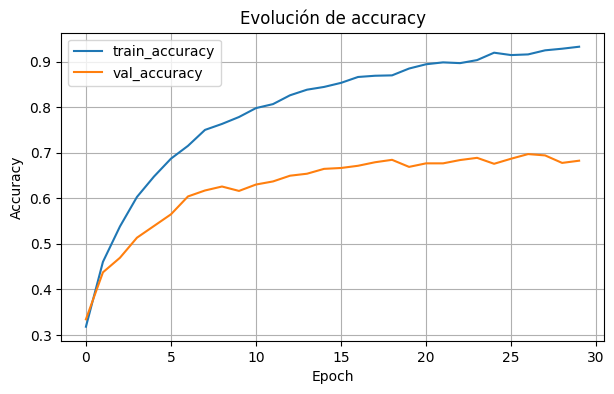

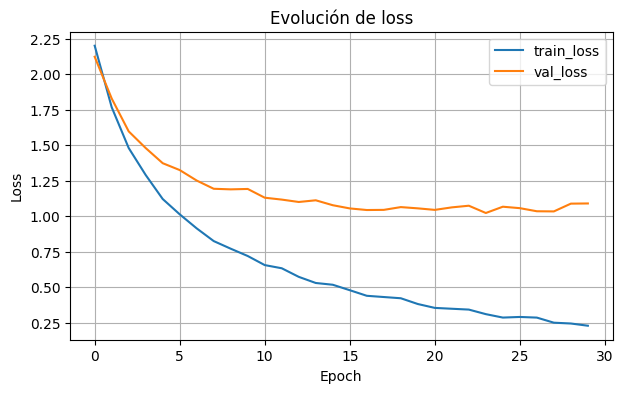

In [27]:
import matplotlib.pyplot as plt
# Se la evolución de loss y accuracy por época

# Accuracy
plt.figure(figsize=(7, 4))
plt.plot(history_clip.history["accuracy"], label="train_accuracy")
plt.plot(history_clip.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución de accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(7, 4))
plt.plot(history_clip.history["loss"], label="train_loss")
plt.plot(history_clip.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Datos en crudo a csv
history_df = pd.DataFrame(history_clip.history)
history_df.insert(0, "epoch", range(1, len(history_df) + 1))
history_df.to_csv("training_history_Classifier.csv", index=False)

In [34]:
from sklearn.metrics import classification_report
import numpy as np

y_logits = classifier_clip.predict(validation_clip_ds)
y_pred = np.argmax(y_logits, axis=1)

report=classification_report(
    y_eval,
    y_pred,
    target_names=class_names,
    digits=2
)

print(report)

65/65 [==============================] - 0s 588us/step
                                       precision    recall  f1-score   support

         Fringillidae_Serinus_serinus       0.67      0.70      0.69       155
         Paridae_Hypocnemis_peruviana       0.61      0.41      0.49        34
             Paridae_Saxicola_rubetra       0.67      0.76      0.71       409
            Paridae_Saxicola_rubicola       0.54      0.57      0.56       213
                           Sin_Pajaro       0.32      0.32      0.32        19
      Troglodytidae_Troglodytes_aedon       0.66      0.72      0.69       252
   Troglodytidae_Troglodytes_hiemalis       0.95      0.80      0.87        70
  Troglodytidae_Troglodytes_pacificus       0.82      0.51      0.63        90
Troglodytidae_Troglodytes_troglodytes       0.73      0.77      0.75       261
    Turdidae_Catharus_aurantiirostris       0.63      0.59      0.61       154
           Turdidae_Catharus_fuscater       0.86      0.73      0.78       

In [39]:
type(report)

str

In [46]:
# Reporte a md
with open("classification_report.md", "w", encoding="utf-8") as f:
    f.write("# Classification Report\n\n")
    f.write("```text\n")
    f.write(report)
    f.write("\n```")

In [ ]:

os.makedirs("models", exist_ok=True)
classifier_clip.save("models/best_temporal_classifier.keras")
print("Modelo guardado")

Modelo guardado


In [30]:
class_mapping = train_df[["class_id", "label"]].drop_duplicates().sort_values("class_id")
class_mapping.to_csv("models/class_mapping.csv", index=False)